# Page blocks Dataset: Pooled Top-k Ranking Experiment (multi-class)

This notebook runs a ranking-based LazyFCA experiment on the page_blocks dataset.

The page_blocks dataset has **5 classes** (text, horizontal line, picture, vertical line, graphic — relabelled as `0..4`), so the multi-class API of `LazyFCA` is used here: every classifier votes for one of the 5 classes and predictions are 5-vector probability distributions.

Main idea:
- keep the usual baseline thresholds only as a permissive pre-filter,
- for each query object, pool the per-class classifiers from all classes into one list,
- rank the pooled classifiers by one chosen metric,
- keep only the Top-k classifiers from that pooled list,
- classify using only those Top-k classifiers (count per class, weight, normalize),
- plot the macro-averaged F1 as a function of k.

This differs from the threshold notebook because it does not sweep a metric threshold. Instead, it turns the explanation into a ranked list and truncates it directly.

In [5]:
DATASET_NAME = 'page_blocks'

In [6]:
import os
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MPLCONFIGDIR = ROOT / "experiments" / ".matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.model_selection
import tqdm.auto as tqdm

PLOTS_DIR = ROOT / "experiments" / "generated_plots" / f"{DATASET_NAME}_topk_ranking_raw"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

from lazyfca.lazyfca import LazyFCA
from utils.estimate_quality import estimate_quality

In [7]:
pd.set_option("display.max_columns", None)

data = pd.read_csv(f"../datasets/{DATASET_NAME}.csv")

X = data.drop(columns=["class"])
y = data["class"].to_numpy()

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y,
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

X_train.shape, X_test.shape

((4925, 10), (548, 10))

In [8]:
data['class'].value_counts()

class
0    4913
1     329
4     115
3      88
2      28
Name: count, dtype: int64

## Baseline Threshold Params

`LazyFCA.Params(...)` is the threshold object used by LazyFCA.

Important detail:
- this object reuses the same dataclass as the metrics themselves,
- but when passed into `LazyFCA(...)`, its values are interpreted as lower/upper bounds for filtering classifiers.

Example:
- `supporters_covered=1` means keep only classifiers covering at least 1 supporter,
- `supporter_opposer_ratio=1.0` means keep only classifiers whose supporter/opposer ratio is at least 1.0.

Here we keep the same baseline thresholds as in the original page_blocks notebook. They serve only as a permissive pre-filter before ranking.

In [9]:
N_CLASSES = int(y_train.max()) + 1

baseline_classifier = LazyFCA(n_classes=N_CLASSES)
baseline_classifier.fit(X_train, y_train)

LazyFCA
  Status       : fitted
  Classes      : 5
  Dataset      : 4925 samples (class_0=4421, class_1=296, class_2=25, class_3=79, class_4=104)
  Features     : 0 binary, 10 numeric

  Filtering thresholds
  ------------------------------------
  class_0_params: (none)
  class_1_params: (none)
  class_2_params: (none)
  class_3_params: (none)
  class_4_params: (none)
  weights       : [1.0, 1.0, 1.0, 1.0, 1.0]

  Ranking & top-k
  ------------------------------------
  class_rank_by : [None, None, None, None, None]
  class_top_k   : [None, None, None, None, None]
  rank_by       : —
  top_k         : —
  minimize_policy: MinimizePolicy.NO_MINIMIZE

In [10]:
# Baseline threshold-only performance for reference.
baseline_y_pred = baseline_classifier.predict(X_test)
baseline_metrics = estimate_quality(baseline_y_pred, y_test)
baseline_metrics

100%|██████████| 548/548 [00:25<00:00, 21.12it/s]


{'Accuracy': 0.8978102189781022,
 'Precision': 0.17956204379562044,
 'Recall': 0.2,
 'F1-score': 0.18923076923076923,
 'AUC-ROC': 0.5}

## Precompute Explanations Once

Efficiency idea:
- explanations are the expensive part,
- threshold sweeps or top-k sweeps should not recompute them,
- we precompute them once using the baseline threshold filter,
- every metric/k experiment reuses those explanations.

In [ ]:
explanations = baseline_classifier.explain(X_test)
len(explanations)

 53%|█████▎    | 290/548 [02:41<02:09,  1.99it/s]

In [ ]:
available_metrics = [
    "supporters_covered",
    "opposers_covered",
    "supporter_opposer_ratio",
    "support",
    "error_rate",
    "precision",
    "lift",
    "wracc",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "interval_tightness",
    "description_volume",
    "simplicity_prior",
    "query_binary_similarity",
    "query_numeric_similarity",
    "query_similarity",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "robustness",
    "delta_stability",
]

## Efficient Pooled Top-k Evaluation

For each explanation and each metric:
1. put positive and negative classifiers in one pooled list,
2. score them by the chosen metric,
3. sort descending,
4. compute cumulative counts of positive and negative classifiers,
5. reuse those cumulative counts for all values of k.

This makes each metric experiment much faster than recomputing `predict()` for every k.

In [ ]:
MINIMIZED_METRICS = {"opposers_covered", "error_rate", "description_volume"}

def metric_score(classifier, metric_name):
    value = classifier.get_metrics().get_metric(metric_name)
    return -value if metric_name in MINIMIZED_METRICS else value

def build_metric_cache(explanations, metric_name, n_classes=N_CLASSES):
    """Cache per-class cumulative counts after sorting all classifiers of an
    explanation by ``metric_name`` (descending).

    For multi-class we pool every per-class classifier list together, tag each
    item with its class index, and compute one cumulative-count vector per
    class. ``predict_from_metric_cache`` can then read the count for every
    class at any cut-off ``k`` in O(1)."""
    cache = []
    for explanation in tqdm.tqdm(explanations, desc=f"Caching {metric_name}"):
        pooled = []
        for class_index, classifiers in enumerate(explanation.class_classifiers):
            for clf in classifiers:
                pooled.append((metric_score(clf, metric_name), class_index))

        if not pooled:
            cache.append({
                "total": 0,
                "cum_per_class": np.zeros((n_classes, 0), dtype=np.int32),
            })
            continue

        pooled.sort(key=lambda item: item[0], reverse=True)
        labels = np.array([cls for _, cls in pooled], dtype=np.int32)

        # cum_per_class[c, i] = number of classifiers of class c among the first i+1 pooled items
        cum_per_class = np.zeros((n_classes, len(labels)), dtype=np.int32)
        for c in range(n_classes):
            cum_per_class[c] = np.cumsum(labels == c)

        cache.append({
            "total": len(labels),
            "cum_per_class": cum_per_class,
        })

    return cache

def predict_from_metric_cache(metric_cache, k, class_weights=None, n_classes=N_CLASSES):
    if class_weights is None:
        class_weights = np.ones(n_classes, dtype=np.float64)
    else:
        class_weights = np.asarray(class_weights, dtype=np.float64)
    assert class_weights.shape == (n_classes,)

    uniform = np.full(n_classes, 1.0 / n_classes, dtype=np.float64)
    y_pred = np.zeros((len(metric_cache), n_classes), dtype=np.float64)

    for i, item in enumerate(metric_cache):
        total_available = item["total"]
        if total_available == 0 or k <= 0:
            y_pred[i] = uniform
            continue

        take = min(k, total_available)
        # counts of each class in the top-`take` pooled classifiers
        counts = item["cum_per_class"][:, take - 1].astype(np.float64)
        weighted = counts * class_weights
        total = float(weighted.sum())
        y_pred[i] = uniform if total == 0 else weighted / total

    return y_pred

def evaluate_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_test, class_weights=None):
    metric_cache = build_metric_cache(explanations, metric_name)
    rows = []

    for k in tqdm.tqdm(k_values, desc=f"Evaluating {metric_name}"):
        y_pred = predict_from_metric_cache(metric_cache, k, class_weights=class_weights)
        metrics = estimate_quality(y_pred, y_true)
        avg_kept = float(np.mean([min(k, item["total"]) for item in metric_cache]))
        rows.append({
            "k": int(k),
            "F1-score": metrics["F1-score"],
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "AUC-ROC": metrics["AUC-ROC"],
            "Average classifiers kept": avg_kept,
        })

    return pd.DataFrame(rows)

def plot_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_test, class_weights=None):
    results = evaluate_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_true, class_weights=class_weights)
    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]
    plot_path = PLOTS_DIR / f"{metric_name}_topk_f1.png"

    plt.figure(figsize=(12, 6))
    plt.plot(results["k"], results["F1-score"], marker="o", linewidth=2)
    plt.axhline(baseline_metrics["F1-score"], color="red", linestyle="--", label="Baseline threshold-only")
    plt.scatter([best_row["k"]], [best_row["F1-score"]], color="green", s=80, zorder=3, label="Best Top-k")
    plt.xlabel("Top-k")
    plt.ylabel("F1-score (macro)")
    plt.title(f"F1-score vs pooled Top-k for metric: {metric_name}")
    plt.xlim(results["k"].max(), results["k"].min())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to: {plot_path}")
    print(f"Best k for {metric_name}: {int(best_row['k'])}")
    print(f"Best F1-score: {best_row['F1-score']:.6f}")
    print(f"Average classifiers kept: {best_row['Average classifiers kept']:.2f}")

    return results

In [ ]:
# Build a top-heavy k-grid from the actual number of pooled classifiers
# (summed across all classes). It always includes 1 and the maximum.
# The grid is intentionally dense near the full classifier count.
max_total_classifiers = max(
    sum(len(cs) for cs in explanation.class_classifiers)
    for explanation in explanations
)

def build_top_heavy_k_grid(max_k, dense_tail=80, mid_points=50, low_points=30):
    if max_k <= 1:
        return np.array([1], dtype=int)

    values = {1, max_k}

    tail_start = max(1, max_k - dense_tail + 1)
    values.update(range(tail_start, max_k + 1))

    t = np.linspace(0.0, 1.0, mid_points)
    mid = np.rint(1 + (max_k - 1) * (t ** 2)).astype(int)
    values.update(mid.tolist())

    low = np.geomspace(1, max_k, low_points)
    low = np.rint(low).astype(int)
    values.update(low.tolist())

    return np.array(sorted(values, reverse=True), dtype=int)

k_values = build_top_heavy_k_grid(max_total_classifiers, dense_tail=80, mid_points=50, low_points=30)
print("Max pooled classifiers:", max_total_classifiers)
print("Number of k values:", len(k_values))
print("First 25 k values:", k_values[:25])
print("Last 25 k values:", k_values[-25:])
k_values

Max pooled classifiers: 4421
Number of k values: 152
First 25 k values: [4421 4420 4419 4418 4417 4416 4415 4414 4413 4412 4411 4410 4409 4408
 4407 4406 4405 4404 4403 4402 4401 4400 4399 4398 4397]
Last 25 k values: [224 185 183 150 137 119 103  91  77  67  58  47  43  32  30  24  18  14
  10   8   6   4   3   2   1]


array([4421, 4420, 4419, 4418, 4417, 4416, 4415, 4414, 4413, 4412, 4411,
       4410, 4409, 4408, 4407, 4406, 4405, 4404, 4403, 4402, 4401, 4400,
       4399, 4398, 4397, 4396, 4395, 4394, 4393, 4392, 4391, 4390, 4389,
       4388, 4387, 4386, 4385, 4384, 4383, 4382, 4381, 4380, 4379, 4378,
       4377, 4376, 4375, 4374, 4373, 4372, 4371, 4370, 4369, 4368, 4367,
       4366, 4365, 4364, 4363, 4362, 4361, 4360, 4359, 4358, 4357, 4356,
       4355, 4354, 4353, 4352, 4351, 4350, 4349, 4348, 4347, 4346, 4345,
       4344, 4343, 4342, 4242, 4068, 3896, 3729, 3565, 3405, 3310, 3248,
       3096, 2946, 2801, 2659, 2521, 2478, 2387, 2256, 2129, 2006, 1886,
       1855, 1770, 1658, 1549, 1444, 1389, 1343, 1245, 1152, 1061, 1040,
        975,  892,  813,  779,  737,  666,  597,  583,  533,  472,  436,
        415,  362,  327,  312,  266,  245,  224,  185,  183,  150,  137,
        119,  103,   91,   77,   67,   58,   47,   43,   32,   30,   24,
         18,   14,   10,    8,    6,    4,    3,   

## Example: WRAcc

Evaluating supporter_opposer_ratio: 100%|██████████| 152/152 [00:00<00:00, 264.90it/s]


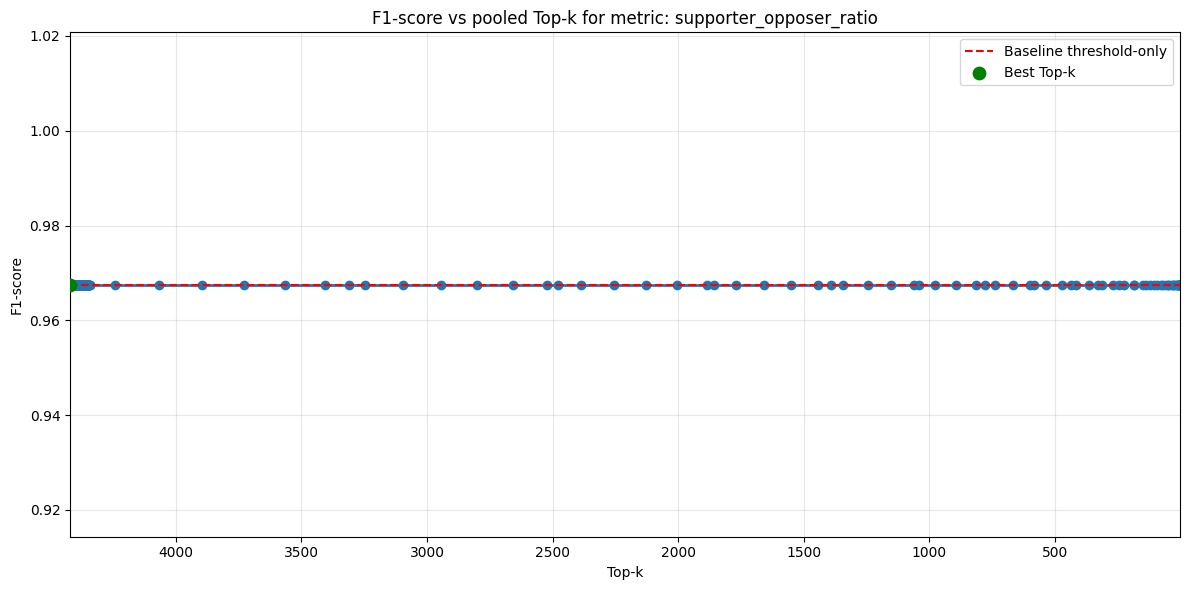

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/supporter_opposer_ratio_topk_f1.png
Best k for supporter_opposer_ratio: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00


,k,F1-score,Accuracy,Precision,Recall,AUC-ROC,Average classifiers kept
0,4421,0.967552,0.937143,0.937143,1.0,0.5,4421.0
1,4420,0.967552,0.937143,0.937143,1.0,0.5,4420.0
2,4419,0.967552,0.937143,0.937143,1.0,0.5,4419.0
3,4418,0.967552,0.937143,0.937143,1.0,0.5,4418.0
4,4417,0.967552,0.937143,0.937143,1.0,0.5,4417.0
...,...,...,...,...,...,...,...
147,6,0.967552,0.937143,0.937143,1.0,0.5,6.0
148,4,0.967552,0.937143,0.937143,1.0,0.5,4.0
149,3,0.967552,0.937143,0.937143,1.0,0.5,3.0
150,2,0.967552,0.937143,0.937143,1.0,0.5,2.0


In [ ]:
wracc_results = plot_metric_topk("supporter_opposer_ratio", k_values)
wracc_results

## Run Any Metric

Examples:
- `plot_metric_topk("precision", k_values)`
- `plot_metric_topk("balanced_precision_proxy", k_values)`
- `plot_metric_topk("information_gain", k_values)`
- `plot_metric_topk("query_weighted_precision", k_values)`
- `plot_metric_topk("stability", k_values)`

Evaluating information_gain: 100%|██████████| 152/152 [00:00<00:00, 257.61it/s]


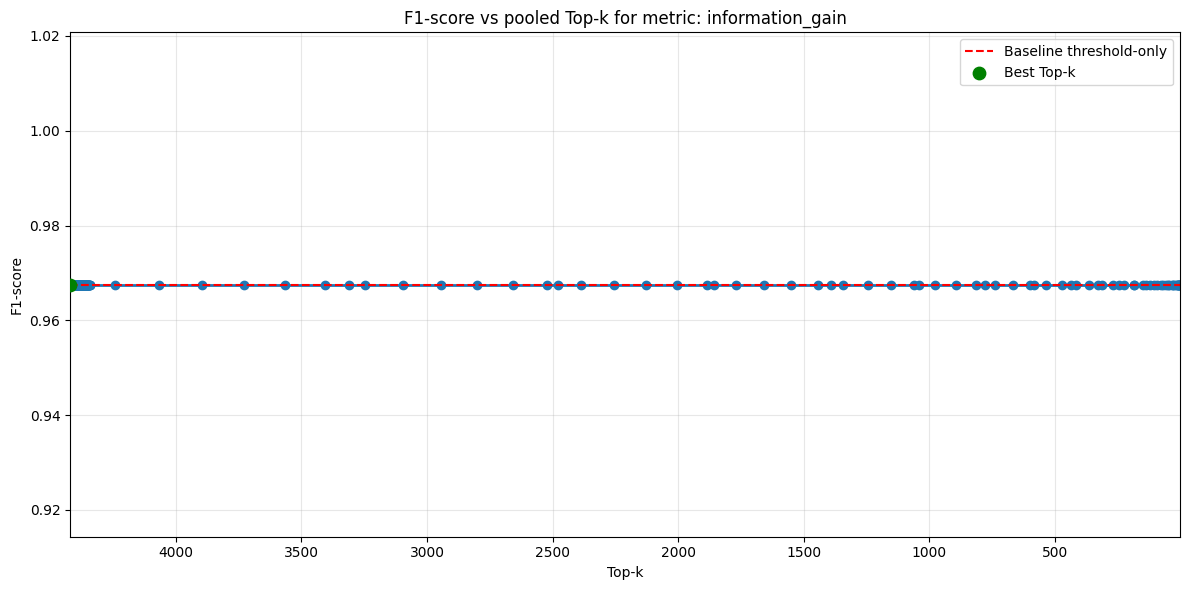

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/information_gain_topk_f1.png
Best k for information_gain: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00


,k,F1-score,Accuracy,Precision,Recall,AUC-ROC,Average classifiers kept
0,4421,0.967552,0.937143,0.937143,1.0,0.5,4421.0
1,4420,0.967552,0.937143,0.937143,1.0,0.5,4420.0
2,4419,0.967552,0.937143,0.937143,1.0,0.5,4419.0
3,4418,0.967552,0.937143,0.937143,1.0,0.5,4418.0
4,4417,0.967552,0.937143,0.937143,1.0,0.5,4417.0
...,...,...,...,...,...,...,...
147,6,0.967552,0.937143,0.937143,1.0,0.5,6.0
148,4,0.967552,0.937143,0.937143,1.0,0.5,4.0
149,3,0.967552,0.937143,0.937143,1.0,0.5,3.0
150,2,0.967552,0.937143,0.937143,1.0,0.5,2.0


In [ ]:
metric_name = "information_gain"
results = plot_metric_topk(metric_name, k_values)
results

## Batch Run Over Several Metrics

This cell is optional. It can take time, but it is still much cheaper than recomputing explanations for every metric and every k.

In [ ]:
metrics_to_try = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

summary_rows = []
for metric_name in metrics_to_try:
    results = evaluate_metric_topk(metric_name, k_values)
    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]
    summary_rows.append({
        "metric": metric_name,
        "best_k": int(best_row["k"]),
        "best_f1": best_row["F1-score"],
        "avg_classifiers_kept": best_row["Average classifiers kept"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="best_f1", ascending=False)
summary_df

Evaluating delta_stability: 100%|██████████| 152/152 [00:00<00:00, 241.36it/s]


,metric,best_k,best_f1,avg_classifiers_kept
0,wracc,4421,0.967552,4421.0
1,lift,4421,0.967552,4421.0
2,balanced_precision_proxy,4421,0.967552,4421.0
3,matthews_correlation,4421,0.967552,4421.0
4,information_gain,4421,0.967552,4421.0
5,gini_gain,4421,0.967552,4421.0
6,chi_squared,4421,0.967552,4421.0
7,g_test,4421,0.967552,4421.0
8,query_weighted_precision,4421,0.967552,4421.0
9,query_weighted_wracc,4421,0.967552,4421.0



=== wracc ===


Evaluating wracc: 100%|██████████| 152/152 [00:00<00:00, 259.21it/s]


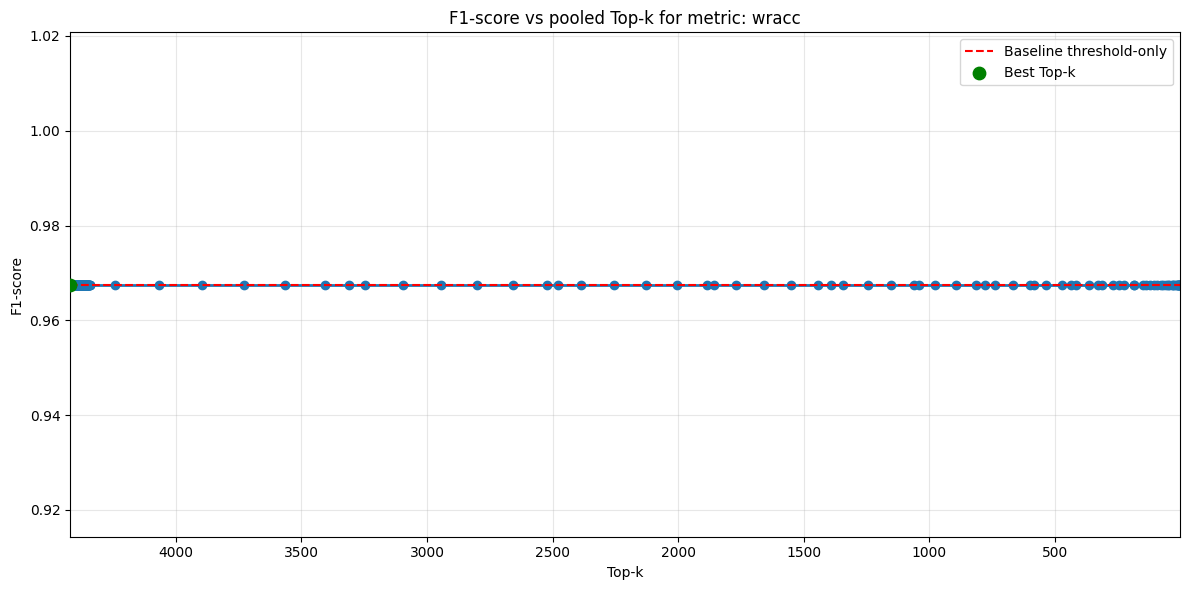

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/wracc_topk_f1.png
Best k for wracc: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== lift ===


Evaluating lift: 100%|██████████| 152/152 [00:00<00:00, 222.82it/s]


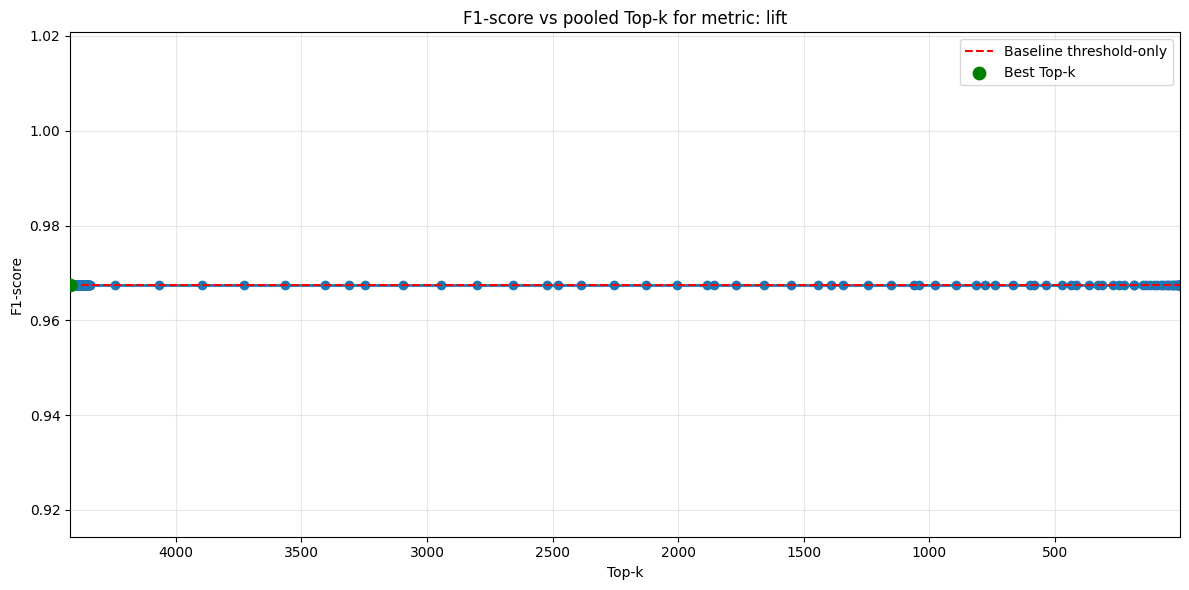

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/lift_topk_f1.png
Best k for lift: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== balanced_precision_proxy ===


Evaluating balanced_precision_proxy: 100%|██████████| 152/152 [00:00<00:00, 277.34it/s]


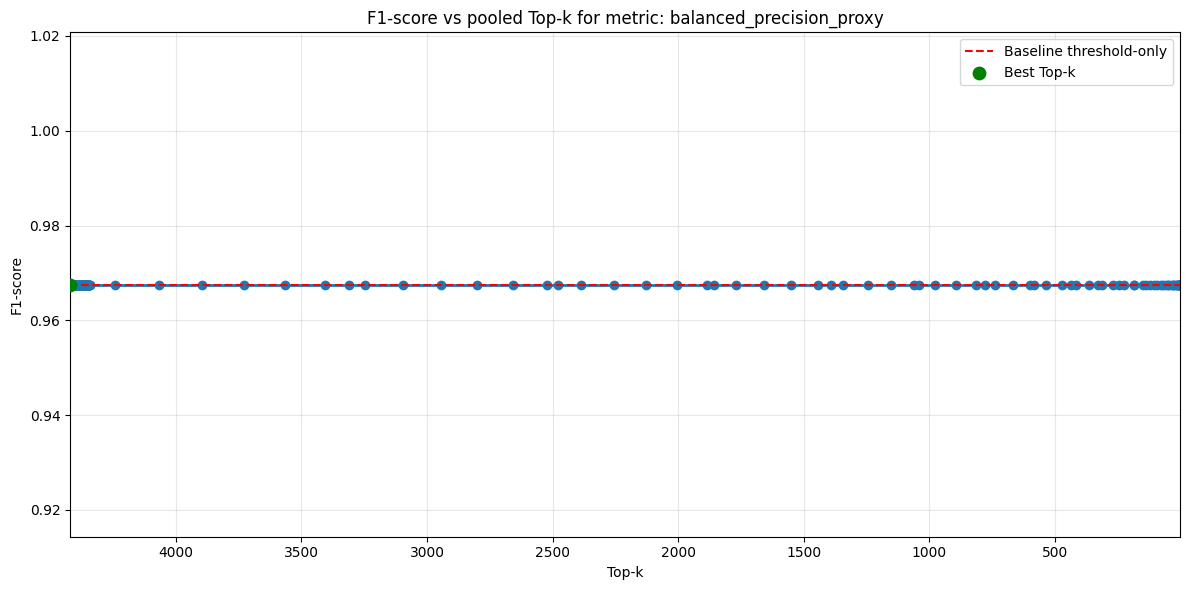

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/balanced_precision_proxy_topk_f1.png
Best k for balanced_precision_proxy: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== youdens_j ===


Evaluating youdens_j: 100%|██████████| 152/152 [00:00<00:00, 278.36it/s]


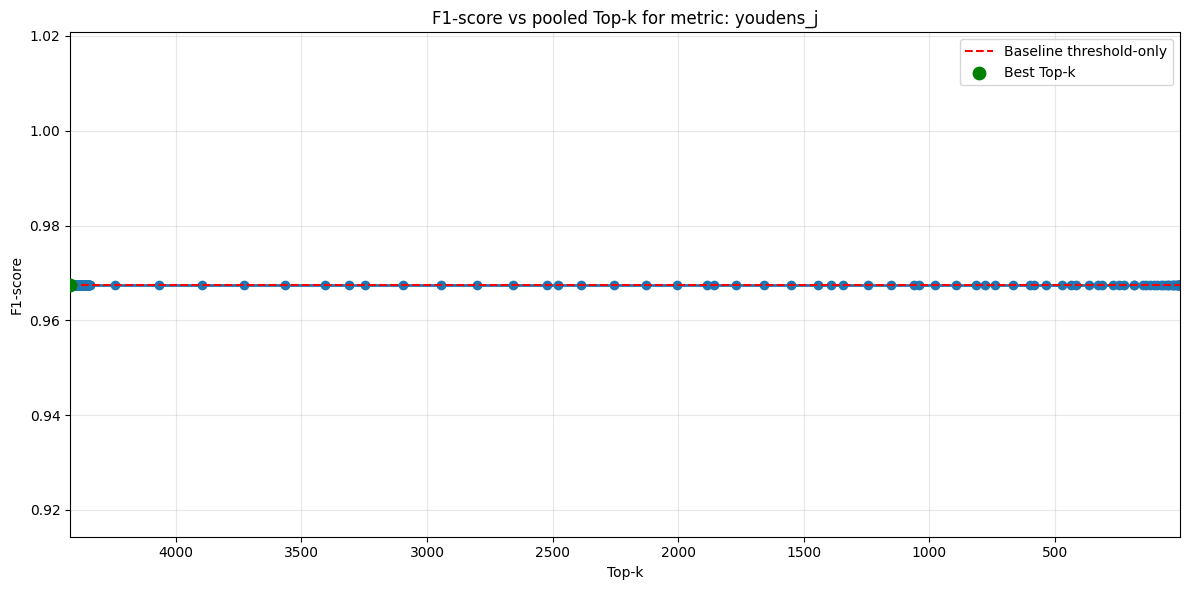

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/youdens_j_topk_f1.png
Best k for youdens_j: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== matthews_correlation ===


Evaluating matthews_correlation: 100%|██████████| 152/152 [00:00<00:00, 269.04it/s]


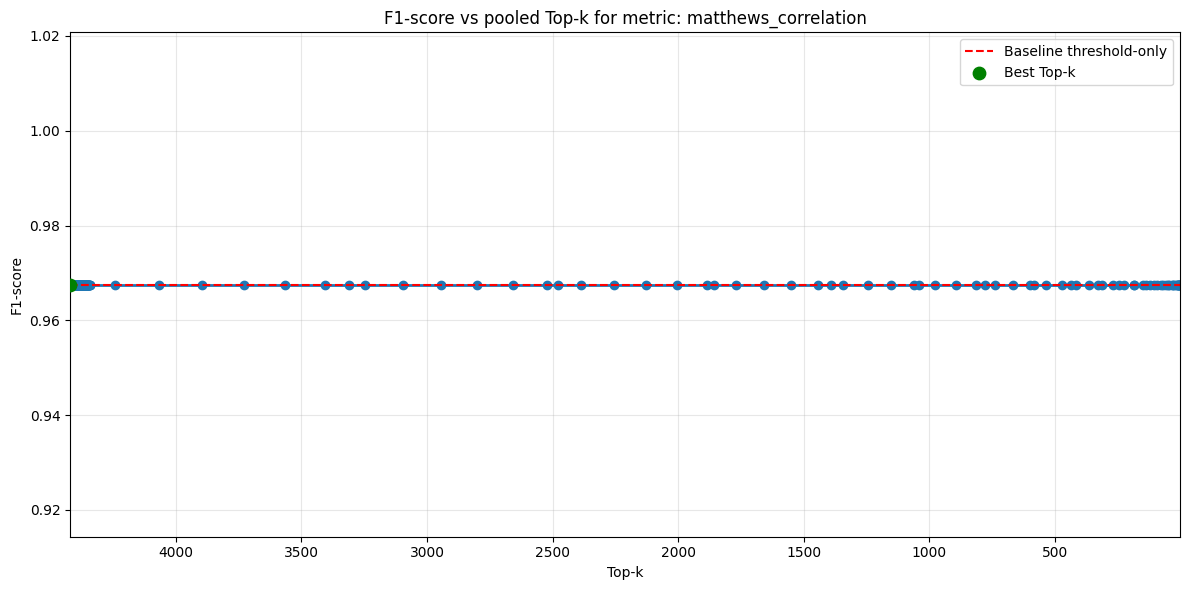

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/matthews_correlation_topk_f1.png
Best k for matthews_correlation: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== information_gain ===


Evaluating information_gain: 100%|██████████| 152/152 [00:00<00:00, 272.47it/s]


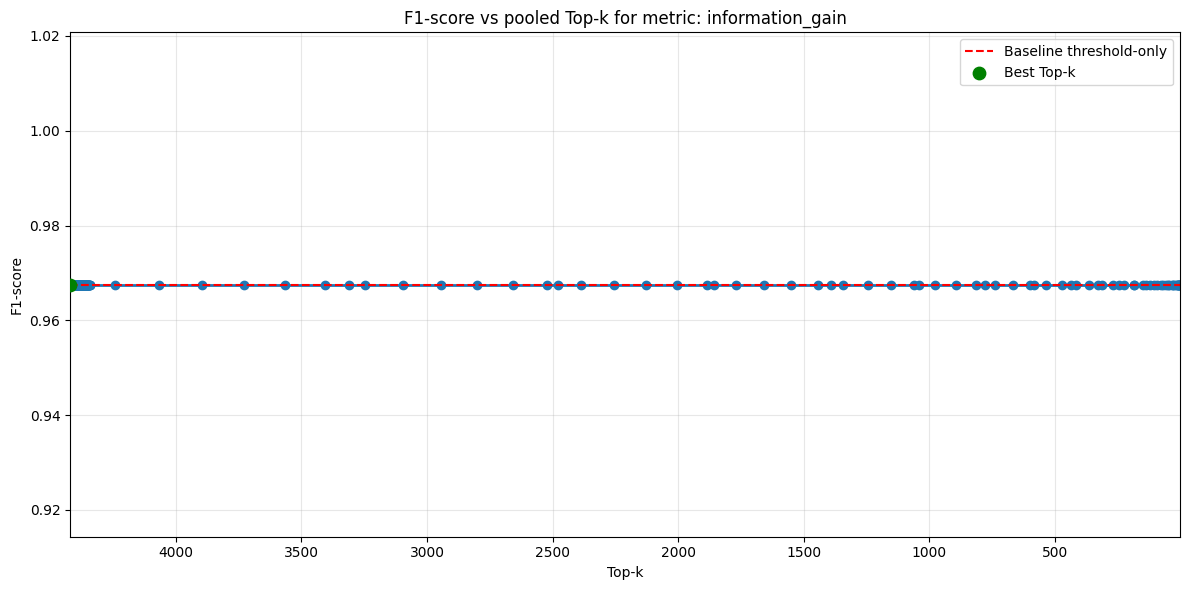

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/information_gain_topk_f1.png
Best k for information_gain: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== gini_gain ===


Evaluating gini_gain: 100%|██████████| 152/152 [00:00<00:00, 251.75it/s]


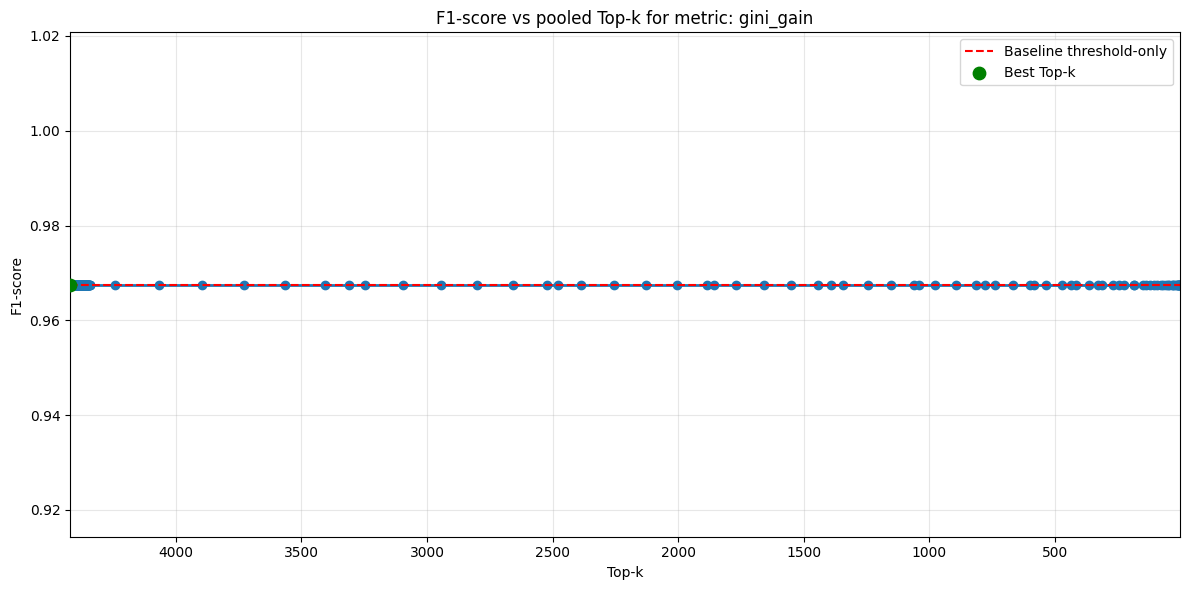

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/gini_gain_topk_f1.png
Best k for gini_gain: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== log_odds_ratio ===


Evaluating log_odds_ratio: 100%|██████████| 152/152 [00:00<00:00, 268.94it/s]


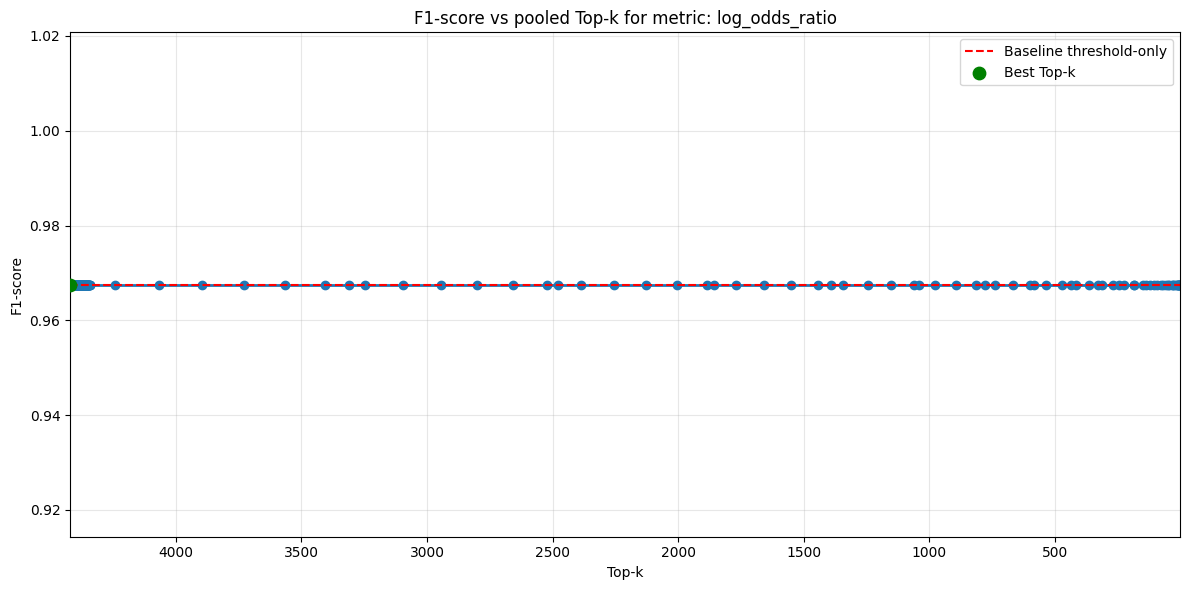

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/log_odds_ratio_topk_f1.png
Best k for log_odds_ratio: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== chi_squared ===


Evaluating chi_squared: 100%|██████████| 152/152 [00:00<00:00, 255.06it/s]


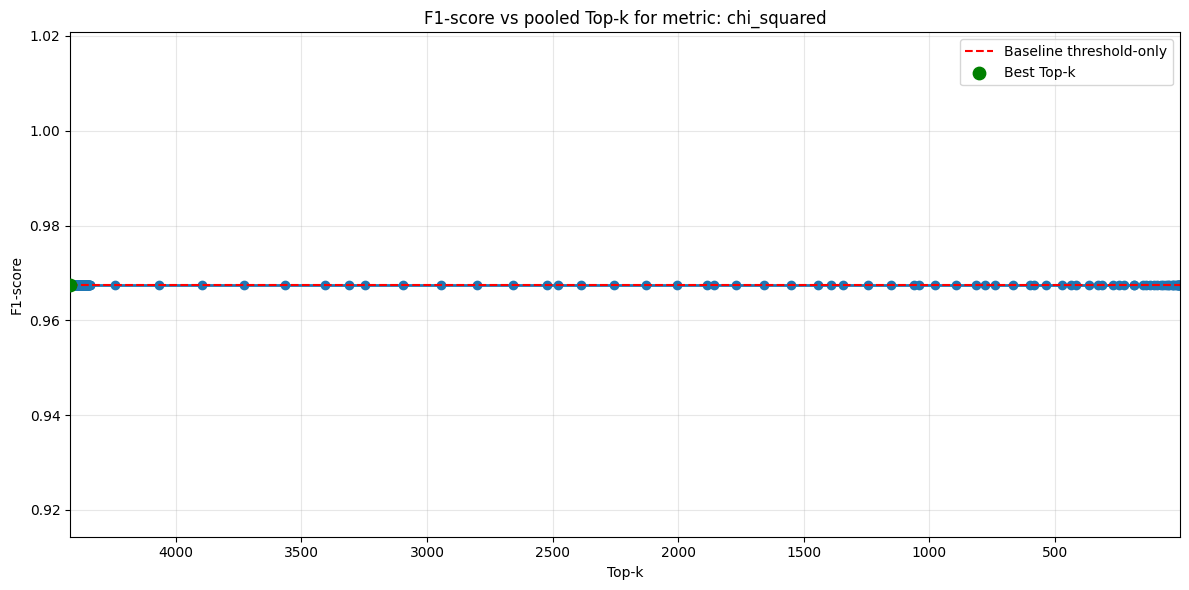

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/chi_squared_topk_f1.png
Best k for chi_squared: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== g_test ===


Evaluating g_test: 100%|██████████| 152/152 [00:00<00:00, 255.96it/s]


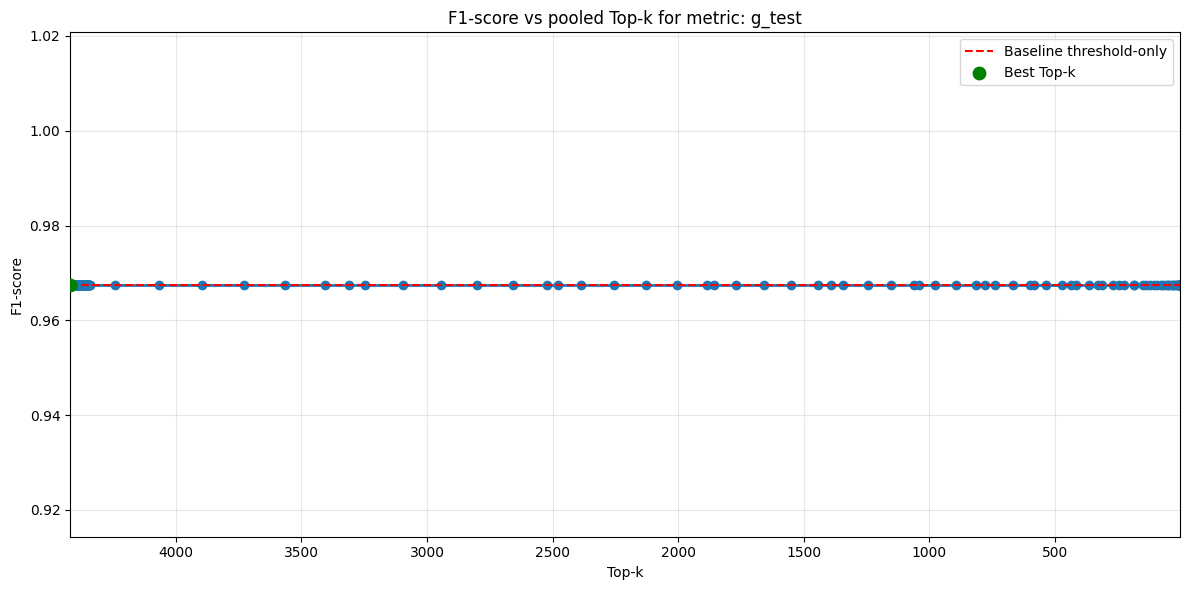

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/g_test_topk_f1.png
Best k for g_test: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== query_weighted_precision ===


Evaluating query_weighted_precision: 100%|██████████| 152/152 [00:00<00:00, 227.84it/s]


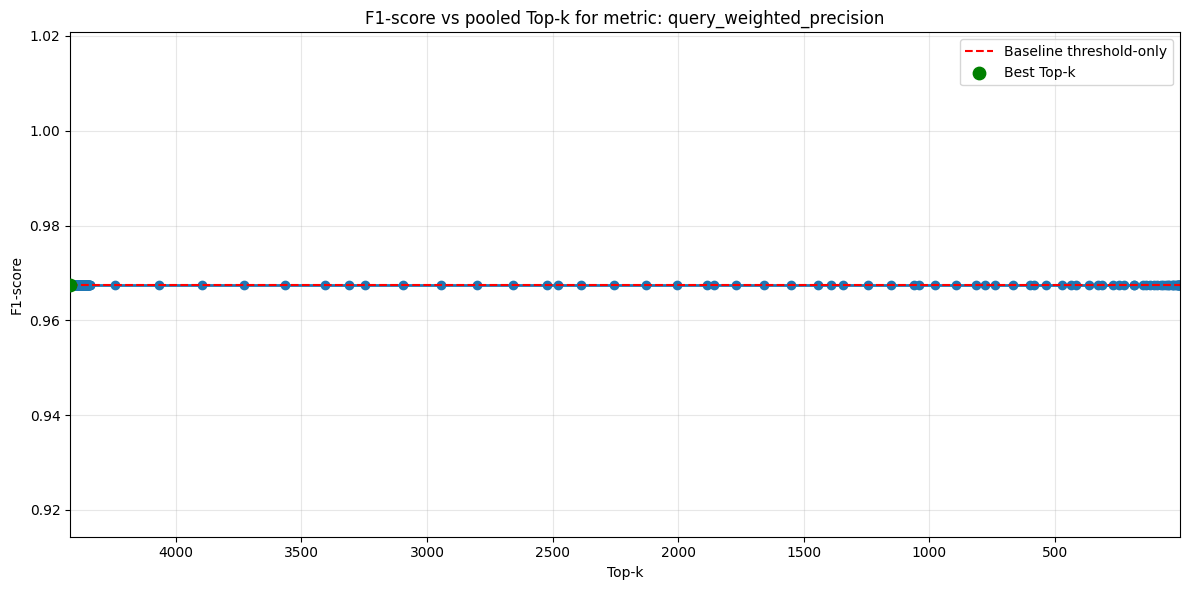

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/query_weighted_precision_topk_f1.png
Best k for query_weighted_precision: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== query_weighted_wracc ===


Evaluating query_weighted_wracc: 100%|██████████| 152/152 [00:00<00:00, 258.38it/s]


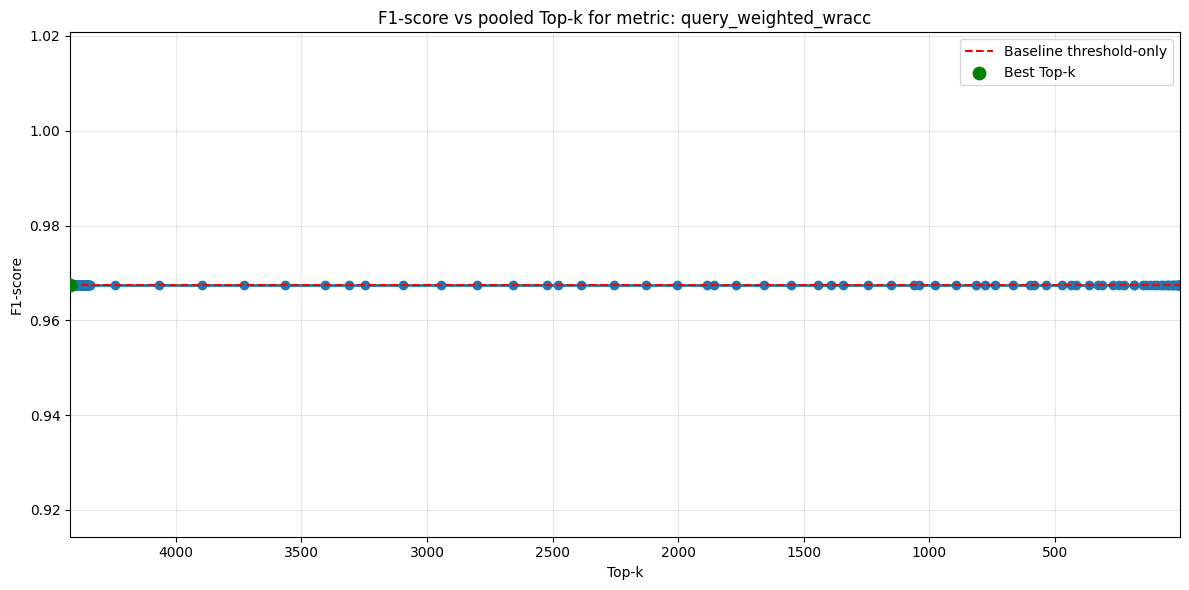

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/query_weighted_wracc_topk_f1.png
Best k for query_weighted_wracc: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== stability ===


Evaluating stability: 100%|██████████| 152/152 [00:00<00:00, 258.89it/s]


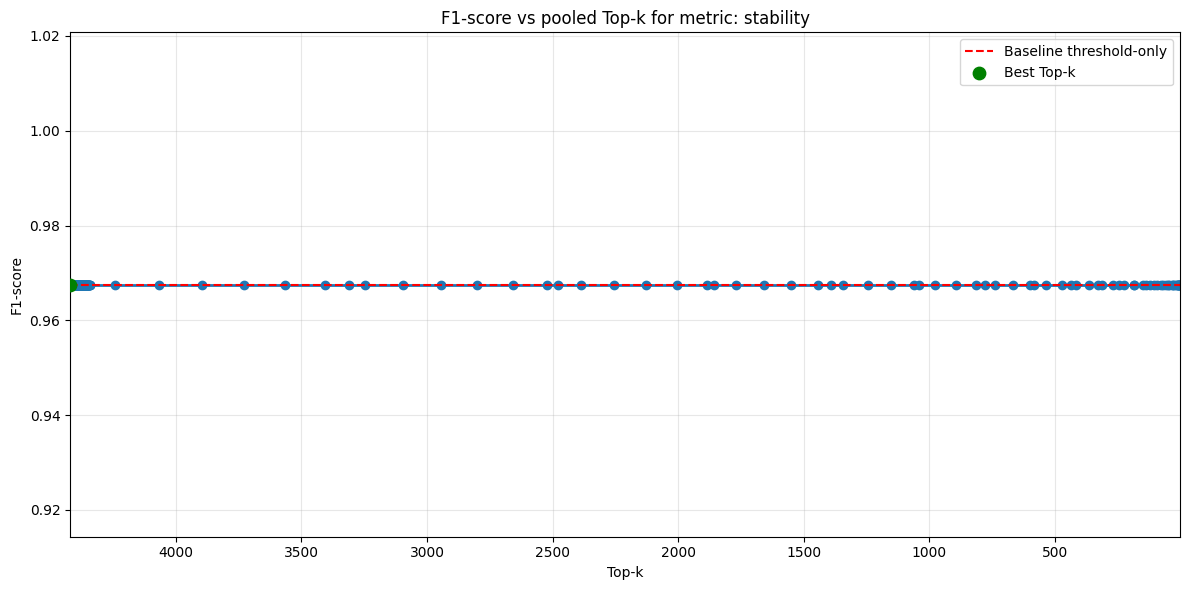

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/stability_topk_f1.png
Best k for stability: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00

=== delta_stability ===


Evaluating delta_stability: 100%|██████████| 152/152 [00:00<00:00, 255.24it/s]


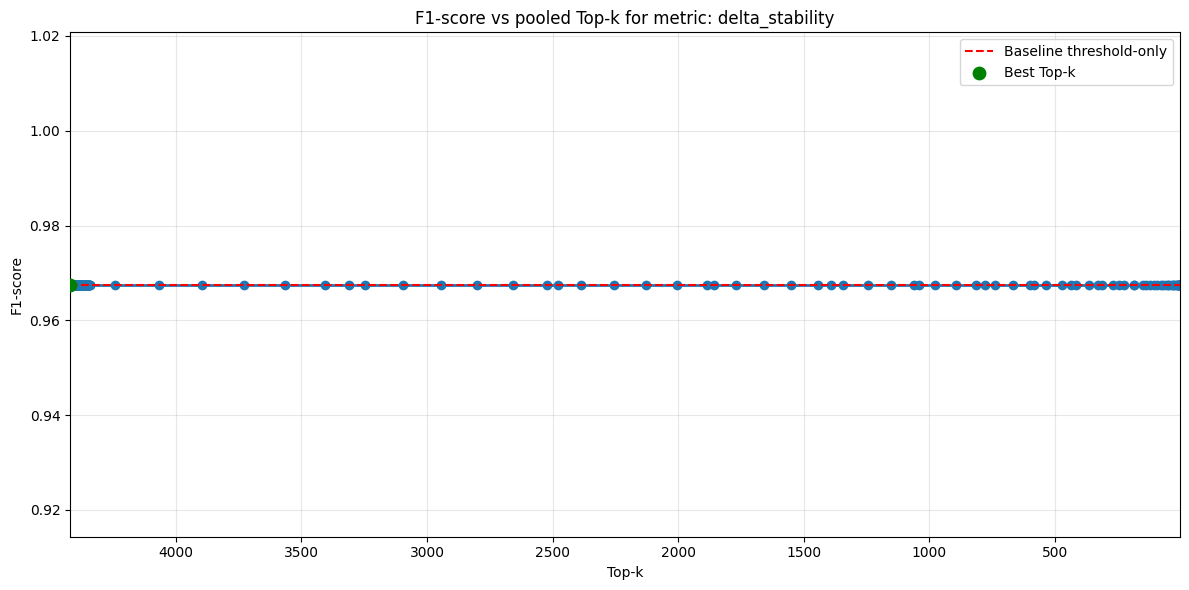

Saved plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/delta_stability_topk_f1.png
Best k for delta_stability: 4421
Best F1-score: 0.967552
Average classifiers kept: 4421.00


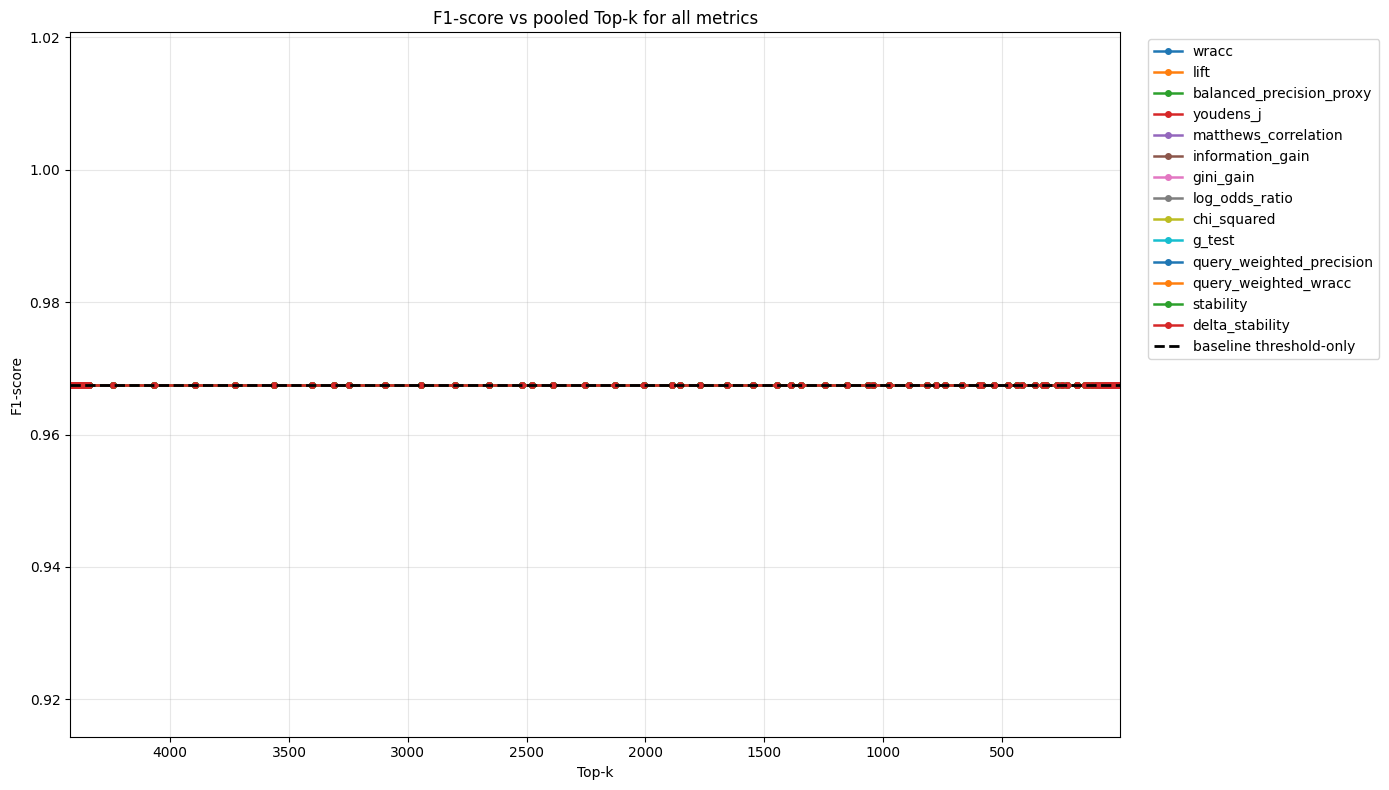


Saved combined plot to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/all_metrics_topk_f1.png
Saved summary CSV to: /Users/raimova-al/Documents/study/master/OSDA/OSDA-LazyFCA/experiments/generated_plots/page_blocks_topk_ranking_raw/topk_summary.csv


,metric,best_k,best_f1,avg_classifiers_kept
0,wracc,4421,0.967552,4421.0
1,lift,4421,0.967552,4421.0
2,balanced_precision_proxy,4421,0.967552,4421.0
3,youdens_j,4421,0.967552,4421.0
4,matthews_correlation,4421,0.967552,4421.0
5,information_gain,4421,0.967552,4421.0
6,gini_gain,4421,0.967552,4421.0
7,log_odds_ratio,4421,0.967552,4421.0
8,chi_squared,4421,0.967552,4421.0
9,g_test,4421,0.967552,4421.0


In [ ]:
metrics_to_plot = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

all_results = {}
summary_rows = []

for metric_name in metrics_to_plot:
    print(f"\n=== {metric_name} ===")
    results = plot_metric_topk(metric_name, k_values)
    all_results[metric_name] = results.copy()

    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]

    summary_rows.append({
        "metric": metric_name,
        "best_k": int(best_row["k"]),
        "best_f1": float(best_row["F1-score"]),
        "avg_classifiers_kept": float(best_row["Average classifiers kept"]),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="best_f1", ascending=False)
summary_df.to_csv(PLOTS_DIR / "topk_summary.csv", index=False)

# Combined plot with all metrics together
plt.figure(figsize=(14, 8))
for metric_name, results in all_results.items():
    plt.plot(results["k"], results["F1-score"], marker="o", linewidth=1.8, markersize=4, label=metric_name)

plt.axhline(
    baseline_metrics["F1-score"],
    color="black",
    linestyle="--",
    linewidth=2,
    label="baseline threshold-only"
)

plt.xlabel("Top-k")
plt.ylabel("F1-score")
plt.title("F1-score vs pooled Top-k for all metrics")
plt.xlim(max(k_values), min(k_values))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

combined_plot_path = PLOTS_DIR / "all_metrics_topk_f1.png"
plt.savefig(combined_plot_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"\nSaved combined plot to: {combined_plot_path}")
print(f"Saved summary CSV to: {PLOTS_DIR / 'topk_summary.csv'}")

summary_df


In [ ]:
metric_name = "query_weighted_precision"
k_value = 20

results = evaluate_metric_topk(metric_name, np.array([k_value]))
row = results.iloc[0]

print(f"Metric: {metric_name}")
print(f"Top-k: {int(row['k'])}")
print(f"F1-score: {row['F1-score']:.6f}")
print(f"Accuracy: {row['Accuracy']:.6f}")
print(f"Precision: {row['Precision']:.6f}")
print(f"Recall: {row['Recall']:.6f}")
print(f"AUC-ROC: {row['AUC-ROC']:.6f}")
print(f"Average classifiers kept: {row['Average classifiers kept']:.2f}")


Evaluating query_weighted_precision: 100%|██████████| 1/1 [00:00<00:00, 68.65it/s]

Metric: query_weighted_precision
Top-k: 20
F1-score: 0.967552
Accuracy: 0.937143
Precision: 0.937143
Recall: 1.000000
AUC-ROC: 0.500000
Average classifiers kept: 20.00


In [ ]:
def rank_metrics_by_f1_retention(
    metrics_to_check,
    allowed_drop_percent=5.0,
    k_values=k_values,
    baseline_f1=None,
    explanations=explanations,
    y_true=y_test,
    class_weights=None,
):
    """
    Rank metrics by how aggressively they can prune while keeping F1 within
    an allowed percentage drop from baseline.

    Rule:
    - Let baseline F1 be F_base.
    - Allowed minimum F1 is:
          F_min = F_base * (1 - allowed_drop_percent / 100)
    - We scan k_values in descending order (from large k to small k).
    - As soon as F1 drops below F_min, we stop.
    - The selected k is the last valid k before the break.

    Output:
    - A dataframe ordered best -> worst.
    - Best means smaller retained k first.
    - Ties are broken by higher retained F1.
    """

    if baseline_f1 is None:
        baseline_f1 = float(baseline_metrics["F1-score"])

    if allowed_drop_percent < 0:
        raise ValueError("allowed_drop_percent must be non-negative")

    f1_threshold = baseline_f1 * (1.0 - allowed_drop_percent / 100.0)

    rows = []

    for metric_name in metrics_to_check:
        results = evaluate_metric_topk(
            metric_name=metric_name,
            k_values=k_values,
            explanations=explanations,
            y_true=y_true,
            class_weights=class_weights,
        ).sort_values("k", ascending=False).reset_index(drop=True)

        last_valid_row = None
        broke = False

        for _, row in results.iterrows():
            if row["F1-score"] >= f1_threshold:
                last_valid_row = row
            else:
                broke = True
                break

        if last_valid_row is None:
            rows.append({
                "metric": metric_name,
                "selected_k": np.nan,
                "selected_f1": np.nan,
                "baseline_f1": baseline_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": np.nan,
                "status": "never_satisfies_rule",
            })
        else:
            rows.append({
                "metric": metric_name,
                "selected_k": int(last_valid_row["k"]),
                "selected_f1": float(last_valid_row["F1-score"]),
                "baseline_f1": baseline_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": float(last_valid_row["Average classifiers kept"]),
                "status": "break_found" if broke else "all_k_valid",
            })

    summary = pd.DataFrame(rows)

    # Best -> worst:
    # 1) metrics that satisfy the rule
    # 2) among them, smaller selected_k is better
    # 3) if tied, higher F1 is better
    # 4) metrics that never satisfy the rule go last
    summary["valid"] = summary["selected_k"].notna()

    summary = summary.sort_values(
        by=["valid", "selected_k", "selected_f1"],
        ascending=[False, True, False],
        na_position="last",
    ).reset_index(drop=True)

    return summary.drop(columns=["valid"])


In [ ]:
metrics_to_check = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

rank_metrics_by_f1_retention(
    metrics_to_check=metrics_to_check,
    allowed_drop_percent=5.0,
)


Evaluating delta_stability: 100%|██████████| 152/152 [00:00<00:00, 250.19it/s]


,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,wracc,1,0.967552,0.967552,0.919174,1.0,all_k_valid
1,lift,1,0.967552,0.967552,0.919174,1.0,all_k_valid
2,balanced_precision_proxy,1,0.967552,0.967552,0.919174,1.0,all_k_valid
3,youdens_j,1,0.967552,0.967552,0.919174,1.0,all_k_valid
4,matthews_correlation,1,0.967552,0.967552,0.919174,1.0,all_k_valid
5,information_gain,1,0.967552,0.967552,0.919174,1.0,all_k_valid
6,gini_gain,1,0.967552,0.967552,0.919174,1.0,all_k_valid
7,log_odds_ratio,1,0.967552,0.967552,0.919174,1.0,all_k_valid
8,chi_squared,1,0.967552,0.967552,0.919174,1.0,all_k_valid
9,g_test,1,0.967552,0.967552,0.919174,1.0,all_k_valid


In [ ]:
metrics_to_check = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

rank_metrics_by_f1_retention(
    metrics_to_check=metrics_to_check,
    allowed_drop_percent=1.0,
)


Caching wracc:   0%|          | 0/525 [00:00<?, ?it/s]

Evaluating delta_stability: 100%|██████████| 152/152 [00:00<00:00, 274.01it/s]


,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,wracc,1,0.967552,0.967552,0.957876,1.0,all_k_valid
1,lift,1,0.967552,0.967552,0.957876,1.0,all_k_valid
2,balanced_precision_proxy,1,0.967552,0.967552,0.957876,1.0,all_k_valid
3,youdens_j,1,0.967552,0.967552,0.957876,1.0,all_k_valid
4,matthews_correlation,1,0.967552,0.967552,0.957876,1.0,all_k_valid
5,information_gain,1,0.967552,0.967552,0.957876,1.0,all_k_valid
6,gini_gain,1,0.967552,0.967552,0.957876,1.0,all_k_valid
7,log_odds_ratio,1,0.967552,0.967552,0.957876,1.0,all_k_valid
8,chi_squared,1,0.967552,0.967552,0.957876,1.0,all_k_valid
9,g_test,1,0.967552,0.967552,0.957876,1.0,all_k_valid


In [ ]:
def rank_metrics_by_f1_retention(
    metrics_to_check,
    allowed_drop_percent=5.0,
    k_values=k_values,
    explanations=explanations,
    y_true=y_test,
    class_weights=None,
):
    """
    Rank metrics by how aggressively they can prune while keeping F1 within
    an allowed percentage drop from that metric's own best F1.

    Rule:
    - For each metric m, compute its whole F1(k) curve.
    - Let F_best(m) be the best F1 reached by that metric.
    - Allowed minimum F1 is:
          F_min(m) = F_best(m) * (1 - allowed_drop_percent / 100)
    - We scan k_values in descending order (from large k to small k).
    - We ignore the initial bad region before the metric first reaches F_min(m).
    - Once the metric has entered the valid region, we keep scanning.
    - As soon as F1 drops below F_min(m), we stop.
    - The selected k is the last valid k before the break.

    Output:
    - A dataframe ordered best -> worst.
    - Best means smaller retained k first.
    - Ties are broken by higher retained F1.
    """

    if allowed_drop_percent < 0:
        raise ValueError("allowed_drop_percent must be non-negative")

    rows = []

    for metric_name in metrics_to_check:
        results = evaluate_metric_topk(
            metric_name=metric_name,
            k_values=k_values,
            explanations=explanations,
            y_true=y_true,
            class_weights=class_weights,
        ).sort_values("k", ascending=False).reset_index(drop=True)

        best_f1 = float(results["F1-score"].max())
        f1_threshold = best_f1 * (1.0 - allowed_drop_percent / 100.0)

        seen_valid_region = False
        last_valid_row = None
        broke = False

        for _, row in results.iterrows():
            if row["F1-score"] >= f1_threshold:
                seen_valid_region = True
                last_valid_row = row
            elif seen_valid_region:
                broke = True
                break

        if last_valid_row is None:
            rows.append({
                "metric": metric_name,
                "selected_k": np.nan,
                "selected_f1": np.nan,
                "baseline_f1": best_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": np.nan,
                "status": "never_reaches_own_threshold",
            })
        else:
            rows.append({
                "metric": metric_name,
                "selected_k": int(last_valid_row["k"]),
                "selected_f1": float(last_valid_row["F1-score"]),
                "baseline_f1": best_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": float(last_valid_row["Average classifiers kept"]),
                "status": "break_found" if broke else "all_remaining_k_valid",
            })

    summary = pd.DataFrame(rows)
    summary["valid"] = summary["selected_k"].notna()

    summary = summary.sort_values(
        by=["valid", "selected_k", "selected_f1"],
        ascending=[False, True, False],
        na_position="last",
    ).reset_index(drop=True)

    return summary.drop(columns=["valid"])


In [ ]:
rank_metrics_by_f1_retention(metrics_to_check, 5)

Evaluating delta_stability: 100%|██████████| 152/152 [00:00<00:00, 278.83it/s]


,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,wracc,1,0.967552,0.967552,0.919174,1.0,all_remaining_k_valid
1,lift,1,0.967552,0.967552,0.919174,1.0,all_remaining_k_valid
2,balanced_precision_proxy,1,0.967552,0.967552,0.919174,1.0,all_remaining_k_valid
3,youdens_j,1,0.967552,0.967552,0.919174,1.0,all_remaining_k_valid
4,matthews_correlation,1,0.967552,0.967552,0.919174,1.0,all_remaining_k_valid
5,information_gain,1,0.967552,0.967552,0.919174,1.0,all_remaining_k_valid
6,gini_gain,1,0.967552,0.967552,0.919174,1.0,all_remaining_k_valid
7,log_odds_ratio,1,0.967552,0.967552,0.919174,1.0,all_remaining_k_valid
8,chi_squared,1,0.967552,0.967552,0.919174,1.0,all_remaining_k_valid
9,g_test,1,0.967552,0.967552,0.919174,1.0,all_remaining_k_valid


In [ ]:
rank_metrics_by_f1_retention(metrics_to_check, 1)

Evaluating delta_stability: 100%|██████████| 152/152 [00:00<00:00, 253.22it/s]


,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,wracc,1,0.967552,0.967552,0.957876,1.0,all_remaining_k_valid
1,lift,1,0.967552,0.967552,0.957876,1.0,all_remaining_k_valid
2,balanced_precision_proxy,1,0.967552,0.967552,0.957876,1.0,all_remaining_k_valid
3,youdens_j,1,0.967552,0.967552,0.957876,1.0,all_remaining_k_valid
4,matthews_correlation,1,0.967552,0.967552,0.957876,1.0,all_remaining_k_valid
5,information_gain,1,0.967552,0.967552,0.957876,1.0,all_remaining_k_valid
6,gini_gain,1,0.967552,0.967552,0.957876,1.0,all_remaining_k_valid
7,log_odds_ratio,1,0.967552,0.967552,0.957876,1.0,all_remaining_k_valid
8,chi_squared,1,0.967552,0.967552,0.957876,1.0,all_remaining_k_valid
9,g_test,1,0.967552,0.967552,0.957876,1.0,all_remaining_k_valid
